<a href="https://colab.research.google.com/github/Boubacar5400/Data-visualisation-with-R/blob/main/panel_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#####################################
######### PANEL DATA ANALYSIS #######

**PARTIE A : Analyse descriptive de nos données**



In [1]:
url="https://github.com/Boubacar5400/Dataset/raw/main/paneldata.csv"
import pandas as pd
import numpy as np

# Lien vers le fichier CSV

# Importer les données CSV dans un DataFrame pandas
df= pd.read_csv(url)

# Afficher les premières lignes du DataFrame pour vérification
print(df.head())

   lnhr  lnwg  kids  age  disab  id  year
0  7.58  1.91     2   27      0   1  1979
1  7.75  1.89     2   28      0   1  1980
2  7.65  1.91     2   29      0   1  1981
3  7.47  1.89     2   30      0   1  1982
4  7.50  1.94     2   31      0   1  1983


Définition des variables
lnhr : log of annual hours worked

lnwg : log of hourly wage

kids : number of children

age : age

disab : bad health

id: id

year : year

Details
number of observations : 5320

In [23]:
# statistique descriptive
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
lnhr,5320.0,7.66,0.29,2.77,7.58,7.65,7.78,8.56
lnwg,5320.0,2.61,0.43,-0.26,2.37,2.64,2.86,4.69
kids,5320.0,1.56,1.20,0.00,1.00,2.00,2.00,6.00
age,5320.0,38.92,8.45,22.00,32.00,38.00,45.00,60.00
disab,5320.0,0.06,0.24,0.00,0.00,0.00,0.00,1.00
id,5320.0,266.50,153.59,1.00,133.75,266.50,399.25,532.00
year,5320.0,1983.50,2.87,1979.00,1981.00,1983.50,1986.00,1988.00


In [3]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.graphics.tsaplots as tsap
from statsmodels.compat import lzip
from statsmodels.stats.diagnostic import het_white
from matplotlib import pyplot as plt
import seaborn as sns

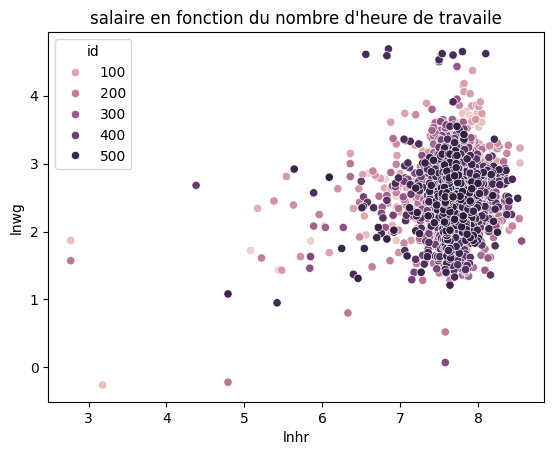

In [8]:
sns.scatterplot(x=df['lnhr'],
                y=df['lnwg'],
                hue=df['id']).set(title=
                "salaire en fonction du nombre d'heure de travaile")

plt.show()

In [9]:
df.columns

Index(['lnhr', 'lnwg', 'kids', 'age', 'disab', 'id', 'year'], dtype='object')

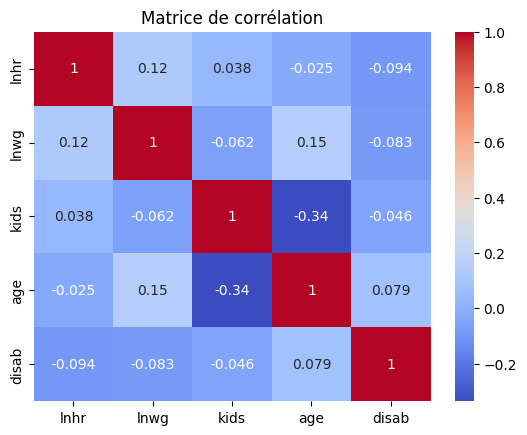

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner les colonnes pour la matrice de corrélation
cols = ['lnhr', 'lnwg', 'kids', 'age', 'disab']
df_corr = df[cols].corr()

# Afficher la matrice de corrélation avec heatmap
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

# Vérification de l'hétérogéneité individuel

<ipython-input-22-8c1f00a76927>:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(x='id', y='lnwg', data=df, ci=None)


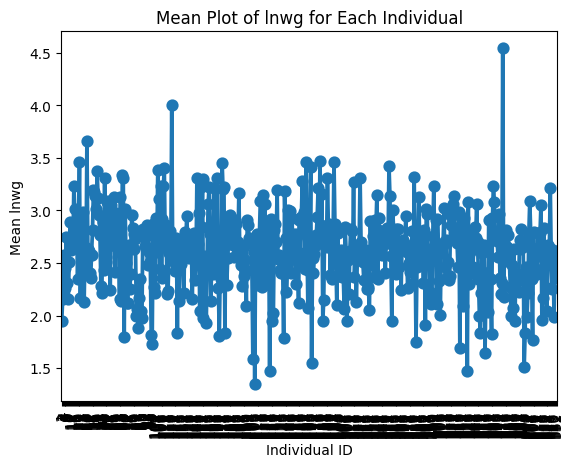

In [22]:
sns.pointplot(x='id', y='lnwg', data=df, ci=None)
plt.title('Mean Plot of lnwg for Each Individual')
plt.xlabel('Individual ID')
plt.ylabel('Mean lnwg')
plt.xticks(rotation=90)
plt.show()

In [ ]:
sns.pointplot(x='id', y='lnwg', data=df, ci=None)
plt.title('Mean Plot of lnwg for Each Individual')
plt.xlabel('Individual ID')
plt.ylabel('Mean lnwg')
plt.xticks(rotation=90)
plt.show()

# Vérification de l'hétérogénéité temporelle

<ipython-input-24-12220bd1ecf9>:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(x='year', y='lnwg', data=df, ci=None)


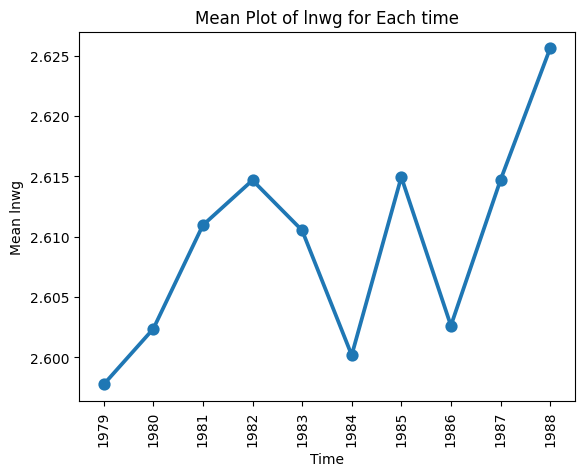

In [24]:
sns.pointplot(x='year', y='lnwg', data=df, ci=None)
plt.title('Mean Plot of lnwg for Each time')
plt.xlabel('Time')
plt.ylabel('Mean lnwg')
plt.xticks(rotation=90)
plt.show()

Au regard des deux graphiques ci dessus, nous pouvons affirmer l'existance d'effets fixes

**PARTIE B : Estimations des modèles**

In [26]:
df.columns

Index(['lnhr', 'lnwg', 'kids', 'age', 'disab', 'id', 'year'], dtype='object')

1) pooled OLS model

In [27]:
pooled_model = sm.OLS(endog=df['lnwg'], exog=df[['lnhr', 'kids', 'age', 'disab']])
pooled_results = pooled_model.fit()
print(pooled_results.summary())

                                 OLS Regression Results                                
Dep. Variable:                   lnwg   R-squared (uncentered):                   0.975
Model:                            OLS   Adj. R-squared (uncentered):              0.975
Method:                 Least Squares   F-statistic:                          5.198e+04
Date:                Thu, 12 Dec 2024   Prob (F-statistic):                        0.00
Time:                        15:38:56   Log-Likelihood:                         -2901.2
No. Observations:                5320   AIC:                                      5810.
Df Residuals:                    5316   BIC:                                      5837.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

2) Fixe effet model

NB: nous pronons en compte les effets fixes individus et temps

In [30]:
fe_model = sm.OLS(endog=df['lnwg'], exog=df[['lnhr', 'kids', 'age', 'disab']], entity=df[['id','year']])
fe_results = fe_model.fit()
print(fe_results.summary())

                                 OLS Regression Results                                
Dep. Variable:                   lnwg   R-squared (uncentered):                   0.975
Model:                            OLS   Adj. R-squared (uncentered):              0.975
Method:                 Least Squares   F-statistic:                          5.198e+04
Date:                Thu, 12 Dec 2024   Prob (F-statistic):                        0.00
Time:                        15:45:41   Log-Likelihood:                         -2901.2
No. Observations:                5320   AIC:                                      5810.
Df Residuals:                    5316   BIC:                                      5837.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['entity']
  warnings.warn(msg, ValueWarning)


3) Random effects model

In [31]:
re_model = sm.GLS(endog=df['lnwg'], exog=df[['lnhr', 'kids', 'age', 'disab']], groups=df[['id','year']])
re_results = re_model.fit()
print(re_results.summary())

                                 GLS Regression Results                                
Dep. Variable:                   lnwg   R-squared (uncentered):                   0.975
Model:                            GLS   Adj. R-squared (uncentered):              0.975
Method:                 Least Squares   F-statistic:                          5.198e+04
Date:                Thu, 12 Dec 2024   Prob (F-statistic):                        0.00
Time:                        15:50:31   Log-Likelihood:                         -2901.2
No. Observations:                5320   AIC:                                      5810.
Df Residuals:                    5316   BIC:                                      5837.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['groups']
  warnings.warn(msg, ValueWarning)


Hausman test for Fixe effet vs Random effet

In [32]:
hausman = sm.stats.anova_lm(fe_results, re_results)
print(hausman)

   df_resid         ssr  df_diff  ss_diff   F  Pr(>F)
0    5316.0  927.077101      0.0      NaN NaN     NaN
1    5316.0  927.077101     -0.0     -0.0 NaN     NaN


**PARTIE C : Compare the models using AIC and BIC**

In [33]:
results = pd.DataFrame({'Model': ['Pooled OLS', 'Fixed Effects', 'Random Effects'],
                        'AIC': [pooled_results.aic, fe_results.aic, re_results.aic],
                        'BIC': [pooled_results.bic, fe_results.bic, re_results.bic]})
results['ΔAIC'] = results['AIC'] - min(results['AIC'])
results['AIC Weight'] = np.exp(-0.5 * results['ΔAIC']) / np.sum(np.exp(-0.5 * results['ΔAIC']))
results = results.sort_values(by='AIC')

print(results)

            Model          AIC          BIC       ΔAIC    AIC Weight
0      Pooled OLS  5775.314439  5808.210581   0.000000  1.000000e+00
2  Random Effects  5810.445361  5836.762275  35.130923  2.351890e-08
1   Fixed Effects  5810.445361  5836.762275  35.130923  2.351890e-08


Interprétation : les résultats ci dessus nous montre que le modèle sans effets (Pooled OLS) est meilleur car il a les plus petits AIC ET BIC

**PARTI D : Diagnostique du modèle retenu (Pooled OLS)**

- Testons l'hypothèse $E(ɛ_{it})=0$

In [34]:
print('Mean value of residual errors='+str(pooled_results.resid.mean()))

Mean value of residual errors=2.649843585992554e-15


le resultat montre la moyenne des résidus est presque nulle

- Testons la normalité des résidus  $ɛ_{it}∼N(0,1)$

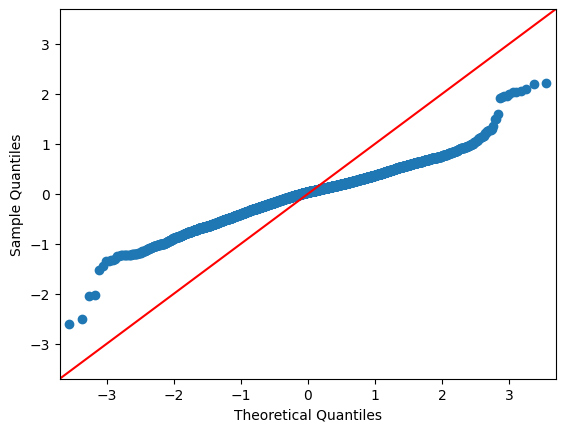

In [35]:
sm.qqplot(data=pooled_results.resid, line='45')
plt.show()

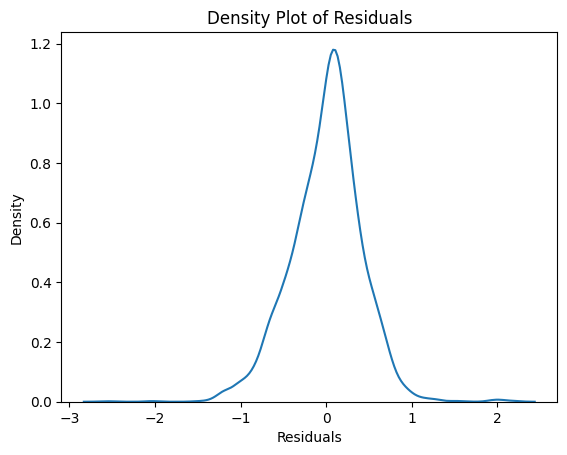

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the density of the residuals
sns.kdeplot(pooled_results.resid)
plt.title('Density Plot of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.show()

Le graphique ci dessus montre que nos résidus suit une distribution normale

- Test l'homoscédasticité des residus $V(ɛ_{it})=σ^2$  $∀$i , $∀$t

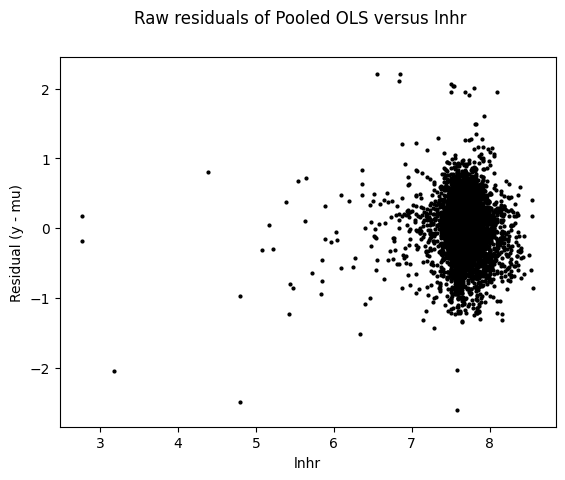

In [39]:
fig, ax = plt.subplots()
fig.suptitle('Raw residuals of Pooled OLS versus lnhr')
plt.ylabel('Residual (y - mu)')
plt.xlabel('lnhr')
ax.scatter(df['lnhr'], pooled_results.resid, s=4, c='black', label='Residual Error')
plt.show()

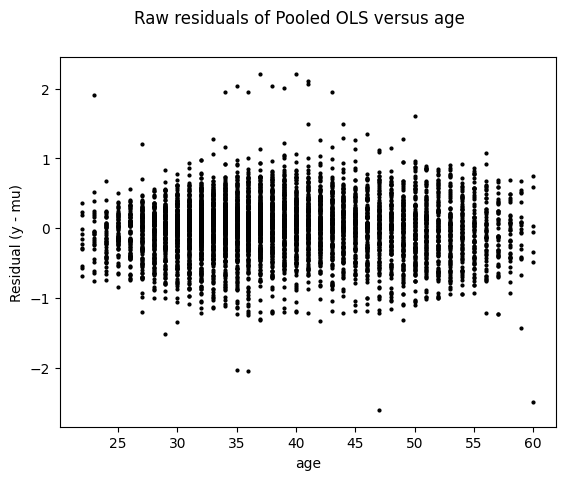

In [40]:
fig, ax = plt.subplots()
fig.suptitle('Raw residuals of Pooled OLS versus age')
plt.ylabel('Residual (y - mu)')
plt.xlabel('age')
ax.scatter(df['age'], pooled_results.resid, s=4, c='black', label='Residual Error')
plt.show()

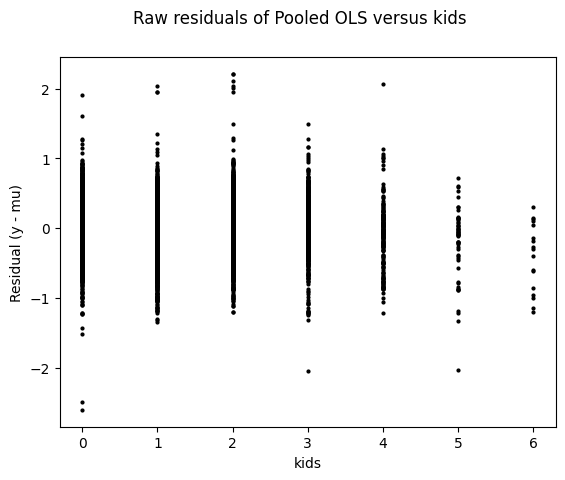

In [41]:
fig, ax = plt.subplots()
fig.suptitle('Raw residuals of Pooled OLS versus kids')
plt.ylabel('Residual (y - mu)')
plt.xlabel('kids')
ax.scatter(df['kids'], pooled_results.resid, s=4, c='black', label='Residual Error')
plt.show()

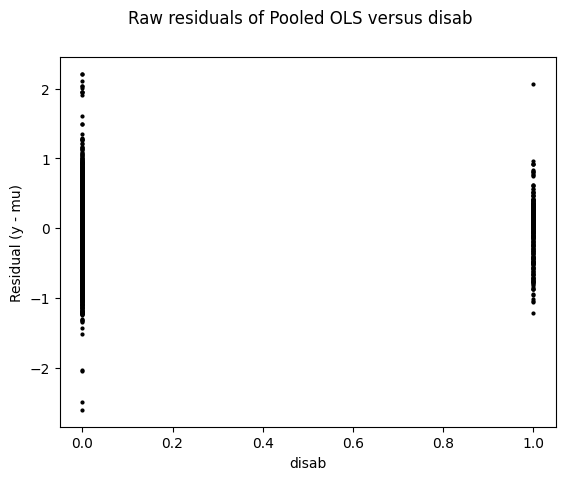

In [42]:
fig, ax = plt.subplots()
fig.suptitle('Raw residuals of Pooled OLS versus disab')
plt.ylabel('Residual (y - mu)')
plt.xlabel('disab')
ax.scatter(df['disab'], pooled_results.resid, s=4, c='black', label='Residual Error')
plt.show()

Graphiquement l'homoscédasticité a été vérifier on le prouvons par la suit avec un test économétrique *Test de White*

In [48]:
import statsmodels.api as sm

# Add a constant term to the exog DataFrame
df['const'] = 1  # Create a new column named 'const' and fill it with ones
results = sm.stats.diagnostic.het_white(resid=pooled_results.resid, exog=df[['const', 'lnhr', 'kids', 'age', 'disab']])

print('Results of the White test for heteroskedasticity of residual errors ===> ')
print(lzip(keys, results))

Results of the White test for heteroskedasticity of residual errors ===> 
[('Lagrange Multiplier statistic:', 244.01338650338943), ("LM test's p-value:", 1.1192238128857633e-44), ('F-statistic:', 19.620816561960382), ("F-test's p-value:", 8.585024995796006e-46)]


Le p_value du test LM est < 0,001, ce qui indique un rejet de l'hypothèse nulle du test de White selon laquelle les résidus sont homoscédastiques.

- Test d'autocorrélation des residus

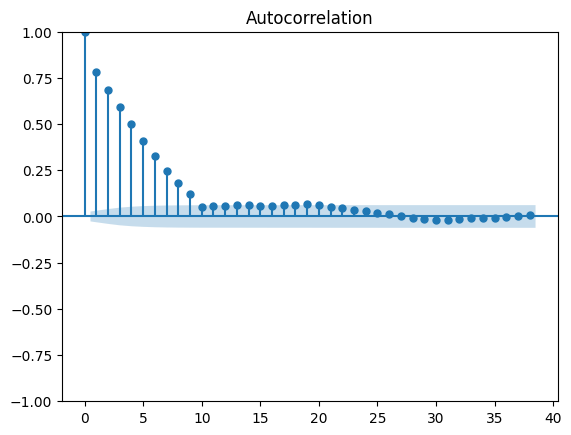

In [51]:
tsap.plot_acf(x=pooled_results.resid)
plt.show()

Les résidus sont auto corrélés